# Tutorial 6 - SOH-C

In [22]:
import matplotlib.pyplot as plt

import pydpeet as eet

eet.set_logging_style("ERROR")

In [23]:
Datas = eet.read(config="neware_8_0_0_516", input_path=r"..\..\res\raw")
Data = eet.merge_into_series(Datas)

In [24]:
Data_segmented = eet.add_primitive_segments(Data)
Data_segmented.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],...,ID,Variable,Duration,Length,Min,Max,Avg,Type,Direction,Slope
0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0.0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,...,1,V,9112.0,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074
1,None,0.0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,...,1,V,9112.0,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074
2,None,0.0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,...,1,V,9112.0,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074
3,None,0.0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,...,1,V,9112.0,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074
4,None,0.0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,...,1,V,9112.0,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074


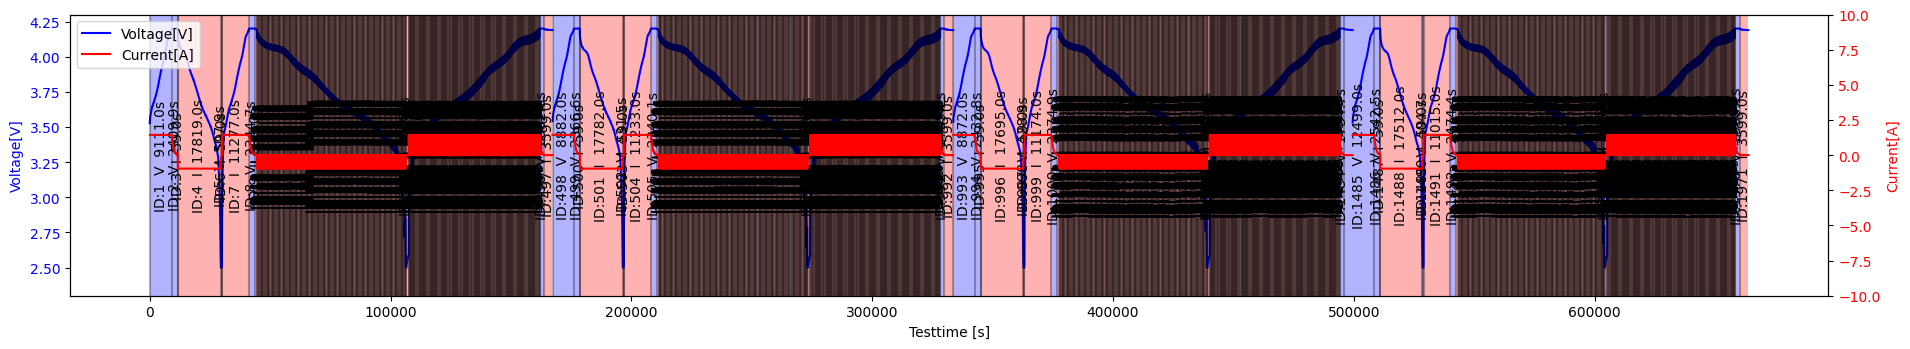

In [25]:
eet.visualize_phases(dataframe=Data_segmented)
plt.show()

In [26]:
Battery_Config = eet.lgm50lt_nmc_4800

results = eet.add_capacity(Data, Data_segmented, neware_bool=True, config=Battery_Config)  # todo: fix
results.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],TestIndex,Capacity[Ah]
0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0.0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None,0.0,NaN
1,None,0.0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None,0.0,NaN
2,None,0.0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None,0.0,NaN
3,None,0.0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None,0.0,NaN
4,None,0.0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None,0.0,NaN


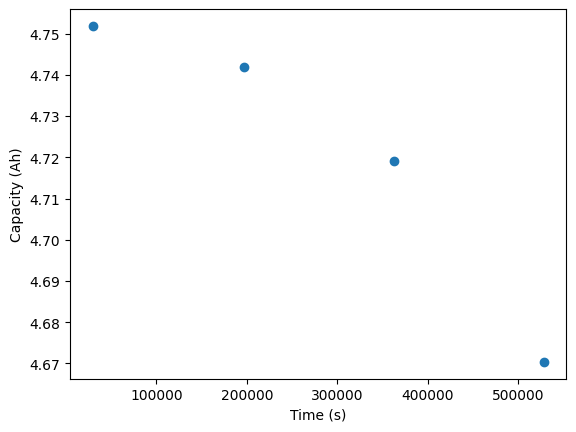

In [28]:
fig, ax = plt.subplots()
ax.plot(Data["Test_Time[s]"], results["Capacity[Ah]"], marker="o")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Capacity (Ah)")
plt.show()